# ------------- data exploration ------------------ 

In [1]:
# imports 
import numpy as np
import pandas as pd
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [2]:
# Download latest version
#path = kagglehub.dataset_download("miadul/customer-churn-prediction-business-dataset")

# Load the dataset
data = pd.read_csv("C:/Users/abdou/Desktop/customer_churn_business_dataset.csv")

# Display a bit of the data to understand its structure
data

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CUST_09996,Female,67,Germany,Sydney,SME,37,Web,Yearly,15,...,34.240174,Service,4.0,1,0.36,0.28,20,Satisfied,2,0
9996,CUST_09997,Male,26,USA,Toronto,Individual,42,Mobile,Yearly,13,...,40.092087,NaN,4.0,0,0.48,0.06,28,Unsatisfied,2,0
9997,CUST_09998,Female,18,Canada,Sydney,Individual,39,Mobile,Yearly,15,...,25.215810,Technical,1.0,0,0.11,0.07,-30,Satisfied,1,0
9998,CUST_09999,Female,30,USA,Delhi,Individual,52,Web,Monthly,14,...,20.544921,NaN,2.0,0,0.25,0.31,58,Neutral,1,1


In [4]:
#first new feature 
data['Total_Revenue'] = data['tenure_months'] * data['monthly_fee']
#second new feature here its over 4 because the tickets calcuted for month and this feature is for the time token for
#each ticket in every week to solve the combline
data['weekly_support_load'] = (data['support_tickets'] * data['avg_resolution_time']) / 4
#third feature is mix betwwen the time token for combline and the monthly log in and i add 1 for smoothing if its 0 he will not dived over 0
data['usage_vs_frustration'] = data['monthly_logins'] / (data['weekly_support_load'] + 1)


In [5]:
# check for missing values
data.isnull().sum()

customer_id                  0
gender                       0
age                          0
country                      0
city                         0
customer_segment             0
tenure_months                0
signup_channel               0
contract_type                0
monthly_logins               0
weekly_active_days           0
avg_session_time             0
features_used                0
usage_growth_rate            0
last_login_days_ago          0
monthly_fee                  0
total_revenue                0
payment_method               0
payment_failures             0
discount_applied             0
price_increase_last_3m       0
support_tickets              0
avg_resolution_time          0
complaint_type            2045
csat_score                   0
escalations                  0
email_open_rate              0
marketing_click_rate         0
nps_score                    0
survey_response              0
referral_count               0
churn                        0
Total_Re

as you can see fifth of complaint_type is empty we have to deal with this if we are using it with our models

In [6]:
# check data types
data.dtypes

customer_id                object
gender                     object
age                         int64
country                    object
city                       object
customer_segment           object
tenure_months               int64
signup_channel             object
contract_type              object
monthly_logins              int64
weekly_active_days          int64
avg_session_time          float64
features_used               int64
usage_growth_rate         float64
last_login_days_ago         int64
monthly_fee                 int64
total_revenue               int64
payment_method             object
payment_failures            int64
discount_applied           object
price_increase_last_3m     object
support_tickets             int64
avg_resolution_time       float64
complaint_type             object
csat_score                float64
escalations                 int64
email_open_rate           float64
marketing_click_rate      float64
nps_score                   int64
survey_respons

prince increase 

In [7]:
# Statistical summary of numerical features
display(data.describe())

# Check for unique values in categorical features
# This helps the 'Redaction' person see if a column has only 1 value (useless)
for col in data.select_dtypes(include=['object']).columns:
    print(f"{col}: {data[col].nunique()} unique values")

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,...,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn,Total_Revenue,weekly_support_load,usage_vs_frustration
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,...,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100,1057.018000,7.244324,7.772329
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,...,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795,1020.148233,7.803118,9.800494
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,...,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000,10.000000,0.000000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,...,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000,340.000000,0.000000,1.330470
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,...,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000,720.000000,5.792061,2.906646
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,...,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000,1440.000000,10.559596,12.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,...,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000,5900.000000,59.423752,54.000000


customer_id: 10000 unique values
gender: 2 unique values
country: 7 unique values
city: 7 unique values
customer_segment: 3 unique values
signup_channel: 3 unique values
contract_type: 3 unique values
payment_method: 3 unique values
discount_applied: 2 unique values
price_increase_last_3m: 2 unique values
complaint_type: 3 unique values
survey_response: 3 unique values


1- there is clear inbalance in the label (churn) we will deal with it
2- nps_score have outlayers min: -100  max: 100  mean: 19  doesnt make since
3- total_revenue have a realy high standerd diviation
4- usage_growth_rate focuse on the negative values since there probably leaving soon if not an outlayer 


5- monthly_logins and weekly_active_days give almost the same information


In [8]:
data.corr(numeric_only=True)['churn'].sort_values(ascending=False)

churn                   1.000000
payment_failures        0.112494
last_login_days_ago     0.037250
email_open_rate         0.011506
age                     0.010155
escalations             0.009561
features_used           0.005435
usage_growth_rate       0.005276
nps_score               0.002996
support_tickets         0.000317
weekly_support_load    -0.000900
marketing_click_rate   -0.002068
avg_session_time       -0.004659
monthly_fee            -0.005048
referral_count         -0.007323
weekly_active_days     -0.008818
avg_resolution_time    -0.009172
usage_vs_frustration   -0.028038
total_revenue          -0.070120
Total_Revenue          -0.070120
monthly_logins         -0.098339
tenure_months          -0.117014
csat_score             -0.157924
Name: churn, dtype: float64

ranking for what featuers are probably significant

In [9]:
churn_summary = data.groupby('churn').mean(numeric_only=True)

differences = (churn_summary.loc[1] / churn_summary.loc[0]) - 1
print("Percentage difference in features for Churners vs Non-Churners:")
print(differences.sort_values())

Percentage difference in features for Churners vs Non-Churners:
total_revenue          -0.218511
Total_Revenue          -0.218511
tenure_months          -0.214336
monthly_logins         -0.159768
csat_score             -0.144232
usage_vs_frustration   -0.115387
referral_count         -0.024166
weekly_active_days     -0.019232
avg_resolution_time    -0.012576
monthly_fee            -0.011339
avg_session_time       -0.006916
marketing_click_rate   -0.003784
weekly_support_load    -0.003202
support_tickets         0.000960
features_used           0.007961
age                     0.012011
email_open_rate         0.017647
nps_score               0.020201
escalations             0.058669
last_login_days_ago     0.128494
usage_growth_rate       0.136037
payment_failures        0.558016
dtype: float64


feauters with insignificant difference can be dealt with

checking types some types will have to be encoded before starting the models 

In [10]:
numeric_cols = data.select_dtypes(include=['number']).columns.drop(['churn', 'customer_id'], errors='ignore')

def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < (Q1 - 1.5 * IQR)) | (series > (Q3 + 1.5 * IQR))).sum()

# Check outliers for all numerical columns
outlier_report = data[numeric_cols].apply(count_outliers).sort_values(ascending=False)
print("Outlier Count per Feature:")
print(outlier_report)

Outlier Count per Feature:
usage_vs_frustration    571
total_revenue           513
monthly_fee             513
Total_Revenue           513
last_login_days_ago     471
weekly_support_load     296
csat_score              221
payment_failures        147
features_used           121
usage_growth_rate        78
monthly_logins           49
escalations              43
avg_resolution_time      38
nps_score                36
avg_session_time         27
support_tickets          18
referral_count            8
age                       0
weekly_active_days        0
tenure_months             0
marketing_click_rate      0
email_open_rate           0
dtype: int64


## ---------important graghs ------------ 

<Axes: xlabel='churn', ylabel='count'>

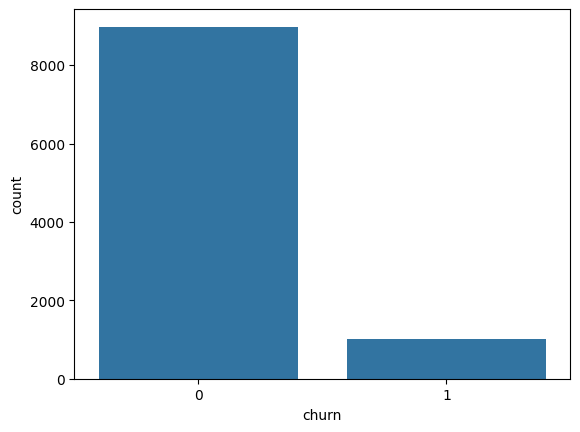

In [56]:
# Visualize churn distribution
sns.countplot(x='churn', data=data)

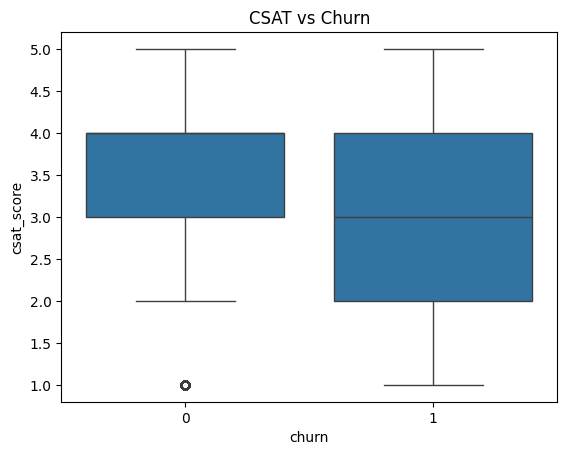

In [63]:
sns.boxplot(x='churn', y='csat_score', data=data)
plt.title("CSAT vs Churn")
plt.show()

the higher the CSAT the more likely they will come back

In [11]:
pd.crosstab(data['price_increase_last_3m'], data['churn'], normalize='index')

churn,0,1
price_increase_last_3m,,
No,0.898324,0.101676
Yes,0.896144,0.103856


there is no real diffrence 

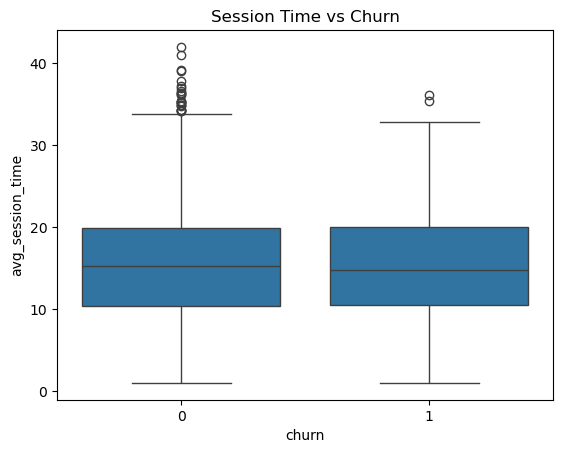

In [12]:
sns.boxplot(x='churn', y='avg_session_time', data=data)
plt.title("Session Time vs Churn")
plt.show()

check after dealing with the nois 

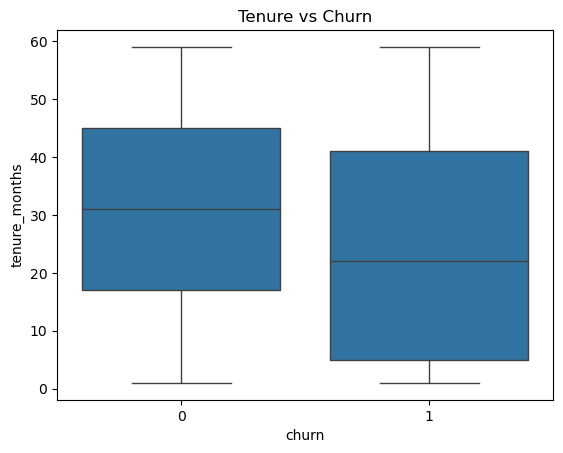

In [13]:
sns.boxplot(x='churn', y='tenure_months', data=data)
plt.title("Tenure vs Churn")
plt.show()

as we get to higher tenure the churn is getting less

In [14]:
contract_churn = data.groupby('contract_type')['churn'].mean()
print(contract_churn)

contract_type
Monthly      0.103282
Quarterly    0.099344
Yearly       0.103379
Name: churn, dtype: float64


not that big of a diffrence 

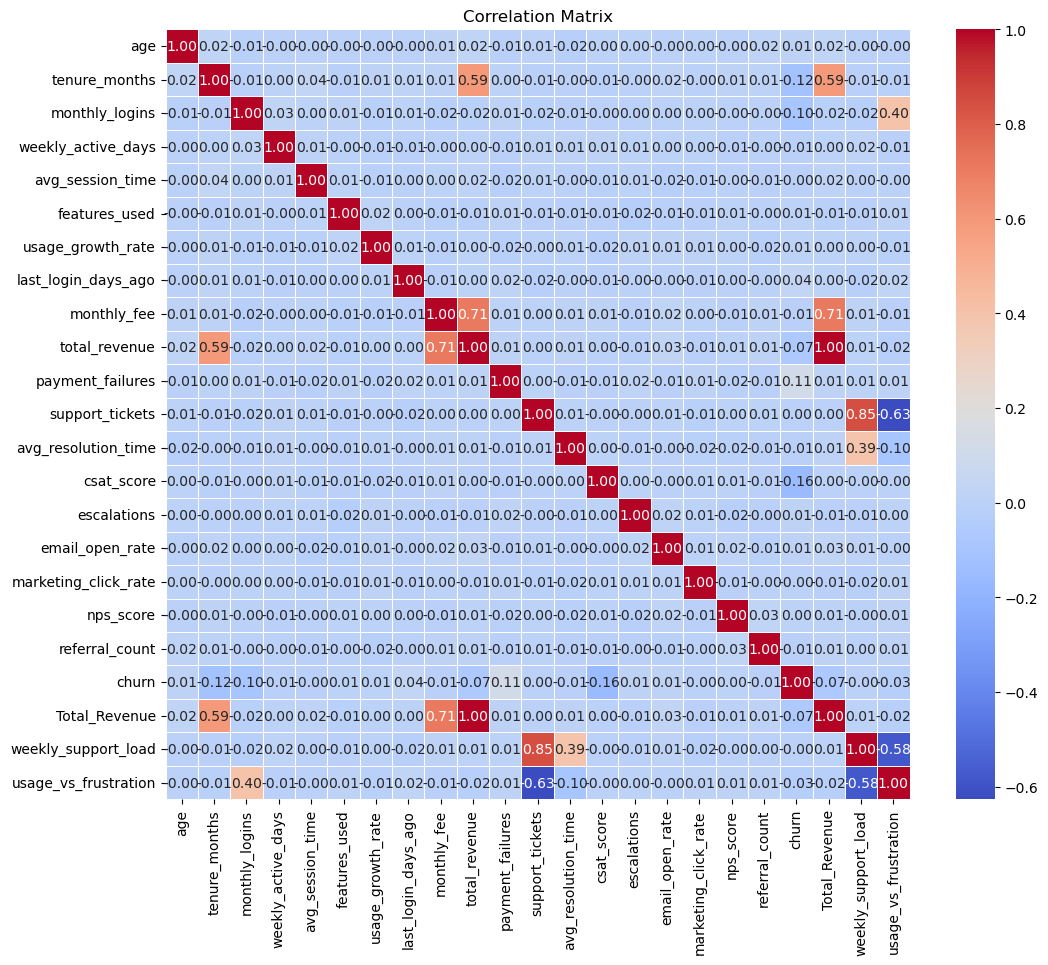

churn                   1.000000
payment_failures        0.112494
last_login_days_ago     0.037250
email_open_rate         0.011506
age                     0.010155
escalations             0.009561
features_used           0.005435
usage_growth_rate       0.005276
nps_score               0.002996
support_tickets         0.000317
weekly_support_load    -0.000900
marketing_click_rate   -0.002068
avg_session_time       -0.004659
monthly_fee            -0.005048
referral_count         -0.007323
weekly_active_days     -0.008818
avg_resolution_time    -0.009172
usage_vs_frustration   -0.028038
total_revenue          -0.070120
Total_Revenue          -0.070120
monthly_logins         -0.098339
tenure_months          -0.117014
csat_score             -0.157924
Name: churn, dtype: float64


In [15]:
corr_matrix = data.select_dtypes(include=['number']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()
print(corr_matrix['churn'].sort_values(ascending=False))

In [16]:
data['complaint_type'] = data['complaint_type'].fillna('No Complaint')

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix ,accuracy_score


x = data.drop(columns=['churn', 'customer_id'], axis=1)
y = data['churn']
#this to convert gender and city and string values to numbers
x = pd.get_dummies(x, drop_first=True)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
weights = compute_sample_weight(class_weight='balanced', y=y_train)
gb=GradientBoostingClassifier(n_estimators=150,learning_rate=0.02,max_depth=4,subsample=0.8,random_state=42)
gb.fit(x_train, y_train, sample_weight=weights)
y_pred = gb.predict(x_test)
print(classification_report(y_test, y_pred))
feature_importance=gb.feature_importances_
feature_importance_series = pd.Series(feature_importance, index=x.columns).sort_values(ascending=False)
features_name = x.columns
print("top 5 Feature Importances:")
print(feature_importance_series.head(5))

              precision    recall  f1-score   support

           0       0.97      0.72      0.83      1780
           1       0.26      0.80      0.39       220

    accuracy                           0.73      2000
   macro avg       0.61      0.76      0.61      2000
weighted avg       0.89      0.73      0.78      2000

top 5 Feature Importances:
tenure_months          0.244903
csat_score             0.233255
monthly_logins         0.155978
payment_failures       0.146006
last_login_days_ago    0.043941
dtype: float64
GradientBoosting Accuracy: 73.05%


In [ ]:
# ok this is bad we have like 220 agent left and 1780 stayed but lets try AdaBoost
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
balanced_base = DecisionTreeClassifier(max_depth=5, class_weight='balanced')
ada = AdaBoostClassifier(estimator=balanced_base,n_estimators=50,learning_rate=0.1,random_state=42)
ada.fit(x_train, y_train)
y_pred_ada = ada.predict(x_test)
print(classification_report(y_test, y_pred_ada))
feature_importance=ada.feature_importances_
feature_importance_series = pd.Series(feature_importance, index=x.columns).sort_values(ascending=False)
print("top 5 Feature Importances for AdaBoost:")
print(feature_importance_series.head(5))

              precision    recall  f1-score   support

           0       0.97      0.72      0.83      1780
           1       0.26      0.80      0.40       220

    accuracy                           0.73      2000
   macro avg       0.62      0.76      0.61      2000
weighted avg       0.89      0.73      0.78      2000

top 5 Feature Importances for AdaBoost:
tenure_months          0.240622
csat_score             0.225194
monthly_logins         0.161984
payment_failures       0.114864
last_login_days_ago    0.059681
dtype: float64
AdaBoost Accuracy: 73.00%


In [23]:
#ok  lets try svm 
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
svm = SVC(kernel='rbf',C=0.1,gamma="auto",class_weight='balanced', probability=True, random_state=42)
svm.fit(x_train_scaled, y_train)
y_pred_svm = svm.predict(x_test_scaled)
print(classification_report(y_test, y_pred_svm))


              precision    recall  f1-score   support

           0       0.94      0.71      0.81      1780
           1       0.20      0.60      0.31       220

    accuracy                           0.70      2000
   macro avg       0.57      0.66      0.56      2000
weighted avg       0.86      0.70      0.75      2000



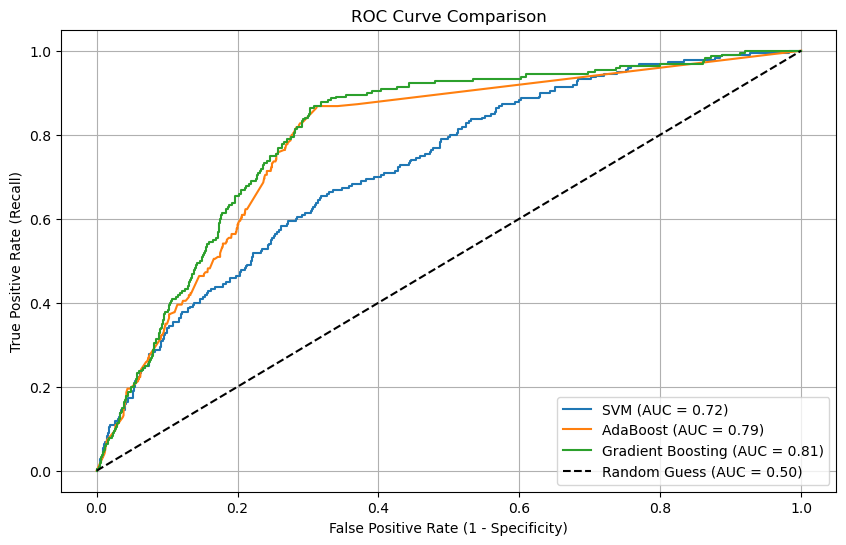

In [24]:
from sklearn.metrics import roc_curve, roc_auc_score

models = {
    'SVM': svm,
    'AdaBoost': ada,
    'Gradient Boosting': gb
}

plt.figure(figsize=(10, 6))

for name, model in models.items():
    # probability=True)
    if name == 'SVM':
        y_probs = model.predict_proba(x_test_scaled)[:, 1]
    else:
        y_probs = model.predict_proba(x_test)[:, 1]
    
     
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc = roc_auc_score(y_test, y_probs)
    
    # الرسم
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

# رسم خط الحظ (Random Guess)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

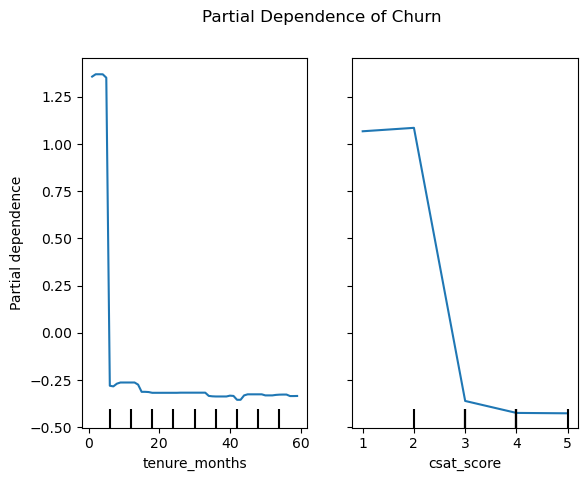

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
features = ['tenure_months', 'csat_score'] # using months , and the evalution from 5 based on the customrs evalute these 2 features are importnat 
PartialDependenceDisplay.from_estimator(gb, x_train, features)
plt.suptitle('Partial Dependence of Churn')
plt.show()